In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer
import joblib
from sklearn.decomposition import PCA


In [3]:
X_train_scaled = pd.read_csv("../data/processed/X_train_scaled.csv")
X_train = pd.read_csv("../data/processed/X_train.csv")
print(f"Ready for clustering with {X_train_scaled.shape[1]} features.")

Ready for clustering with 15 features.


In [4]:
X_train_scaled.isnull().sum()  # to check for null values

gender                            0
age                               0
hypertension                      0
heart_disease                     0
ever_married                      0
Residence_type                    0
avg_glucose_level                 0
bmi                               0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64

In [5]:
X_train_scaled.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0,0.205661,0,0,1,1,-0.960346,0.615716,False,True,False,False,False,True,False
1,1,-1.254901,0,0,0,0,0.632522,-1.079822,False,True,False,False,False,True,False
2,0,1.046590,0,0,1,0,0.277250,-0.533326,False,False,True,False,False,True,False
3,1,0.028623,0,0,1,1,-1.074466,-0.547339,False,True,False,False,False,False,True
4,1,-1.299160,0,0,0,1,-0.566033,0.405525,False,False,False,False,False,False,False


Optimal K identified: 4


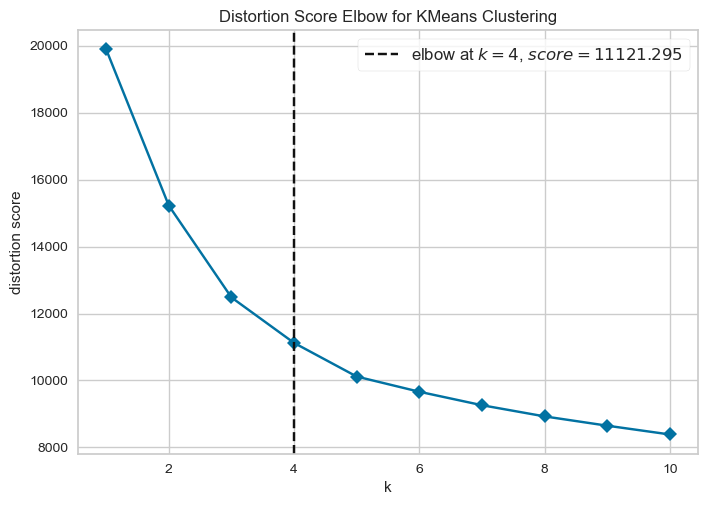

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [6]:
from yellowbrick.cluster.elbow import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Setup the model with the 'dirty fix'
model = KMeans(n_init=10, random_state=42)
model._estimator_type = "clusterer"

# 2. Fit the visualizer
# Use 'distortion' to match the standard Elbow method behavior
visualizer = KElbowVisualizer(model, k=(1,11), metric='distortion', timings=False)
visualizer.fit(X_train_scaled)

# 3. Access the calculated elbow directly from the object
print(f"Optimal K identified: {visualizer.elbow_value_}")

visualizer.show()

In [7]:
# Make sure k is set to 4
k = 4

# Create and fit the model
model_km = KMeans(n_clusters=k, n_init=10, random_state=42)
model_km._estimator_type = "clusterer"


# Get cluster predictions
clusters = model_km.fit_predict(X_train_scaled)

#save model
joblib.dump(model_km, '../artifacts/model_km.pkl')

# Add cluster labels to DataFrames
X_train['Cluster'] = clusters
X_train_scaled['Cluster'] = clusters

# Display cluster distribution
print("Cluster Distribution:")
print(X_train["Cluster"].value_counts().sort_index())

print("\nPercentage distribution:")
print(X_train["Cluster"].value_counts(normalize=True).sort_index() * 100)

Cluster Distribution:
Cluster
0     797
1    1541
2    1071
3     679
Name: count, dtype: int64

Percentage distribution:
Cluster
0    19.496086
1    37.695695
2    26.198630
3    16.609589
Name: proportion, dtype: float64


The cluster distribution shows that cluster 1 contains the highest proportion of patients with a percentage of 37.2% indicating a dominant health profile in the dataset . The remaining clusters are more evenly distributed , representing a distinct subgroups with diffirent health characteristics.

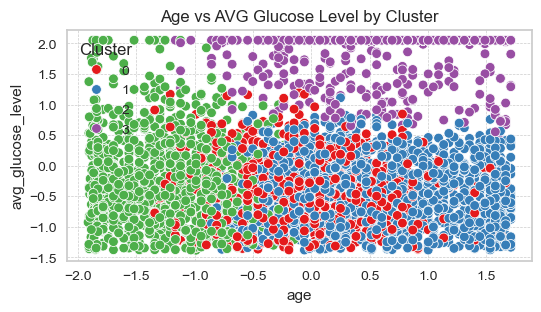

In [8]:
plt.figure(figsize=(6, 3))

sns.scatterplot(
    data=X_train_scaled,
    x="age",
    y="avg_glucose_level",
    hue="Cluster",
    palette="Set1"
)

plt.xlabel("age")
plt.ylabel("avg_glucose_level")
plt.title("Age vs AVG Glucose Level by Cluster")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

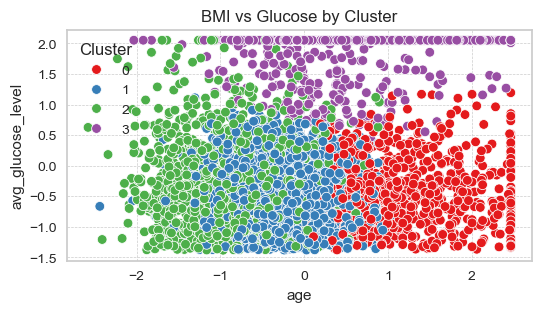

In [9]:
plt.figure(figsize=(6, 3))

sns.scatterplot(
    data=X_train_scaled,
    x="bmi",
    y="avg_glucose_level",
    hue="Cluster",
    palette="Set1"
)

plt.xlabel("age")
plt.ylabel("avg_glucose_level")
plt.title("BMI vs Glucose by Cluster")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

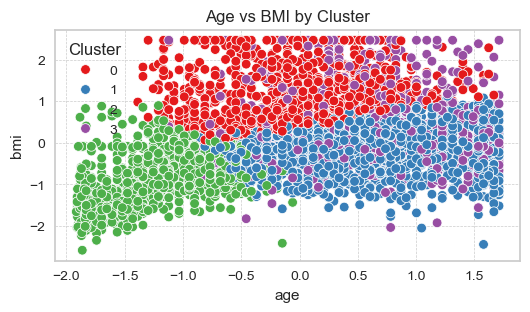

In [10]:
plt.figure(figsize=(6, 3))

sns.scatterplot(
    data=X_train_scaled,
    x="age",
    y="bmi",
    hue="Cluster",
    palette="Set1"
)

plt.xlabel("age")
plt.ylabel("bmi")
plt.title("Age vs BMI by Cluster")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

Scatter Plot interpretation
The scatter plots illustrate hoe the K-Means algorithmn grouped patients based on similarities in their health characteristics . In the Age vs AVG Glucose Level and BMI vs AVG Glucose level plots , the clusters show clearer seperation mainly along the avg_glucose_level axis . This shows that glucose level is one of the strongest features influencing the clustering results . Patients with higher glucose values tend to fall into one dominant cluster , while patients with lower glucose are distributed among the remaining clusters . 

In contrants , The Age vs BMI scatter plots shows greater overlap between clusters , suggesting that age and BMI alone are not sufficient to clearly seperate patients into distinct groups . However , some visible grouping patterns still exist , where certain clusters contain younger patients with lower BMI values , while others contain older patients with moderate to higher BMI

Overall , the scatter plots suggest that avg_glucose_level contributes most strongly to cluster information , while age and BMI provide additional but weaker seperation , resulting in some overlap between clusters.

In [11]:
#To reduce it to two dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_train_scaled)
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters

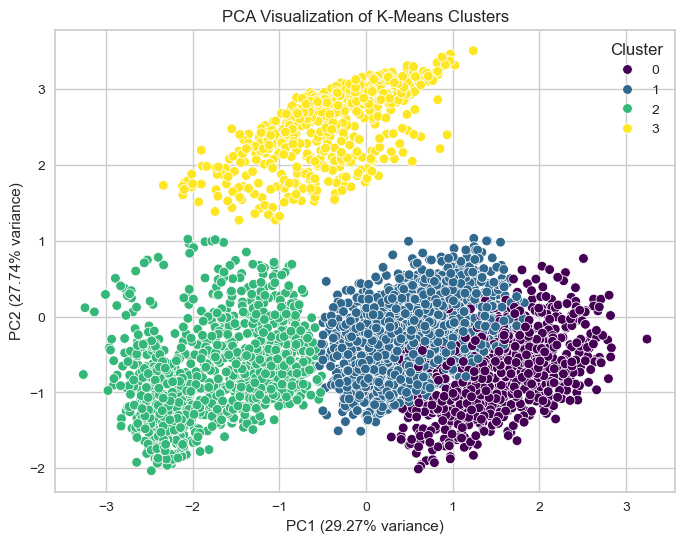

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis"
)

plt.title("PCA Visualization of K-Means Clusters")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.show()

The PCA is applied to reduce the high-dimension into two main components (PC1 and PC2) for visualization purposes . PC1 explains 35.34 and PC2 explains 16.85 of the variance , giving a combined variance of approximately 52% meaning that they provide reasonable low dimensional representation of the data set . The PCA plot shows clear seperation between the four K-means clusters , indicating that the model sucessfully identified distinct patient groups .


In [13]:
cluster_profile = X_train.groupby("Cluster").mean(numeric_only=True)
display(cluster_profile)

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
Cluster,,,,,,,,,,,,,,,
0,0.367629,41.987453,0.099122,0.018821,0.751568,0.499373,87.335772,37.648808,0.001255,0.731493,0.115433,0.006274,0.180678,0.411543,0.204517
1,0.390655,57.097988,0.105775,0.070084,0.922777,0.510058,86.993881,27.190266,0.000000,0.576249,0.255029,0.000000,0.220636,0.401687,0.171966
2,0.449113,14.607134,0.003735,0.000000,0.062558,0.494865,92.902194,22.052848,0.011204,0.408964,0.025210,0.512605,0.061625,0.258637,0.070962
3,0.468336,59.104566,0.222386,0.144330,0.901325,0.522828,162.730773,32.143299,0.000000,0.622975,0.228277,0.000000,0.241532,0.407953,0.179676


## Cluster Interpretations for Stroke Risk (Original Units)

### Cluster 0: "Obese, Middle-Aged" (Moderate-High Risk) 🟠

**Key characteristics:**
- Severely obese (BMI 37.6 kg/m² — Class II/III obesity)
- Middle-aged (42 years average)
- Normal glucose (87 mg/dL)
- Low hypertension (10%) and heart disease (2%)
- 75% ever married, 73% private sector work

**Stroke risk factors:**
- Severe obesity is a major independent stroke risk factor
- Otherwise metabolically healthy

**Intervention focus:** Weight management programs, dietary counseling, physical activity increase

---

### Cluster 1: "Older, Healthy Weight" (Moderate Risk) 🟡

**Key characteristics:**
- Older population (57 years average)
- Overweight but not obese (BMI 27.2 kg/m²)
- Normal glucose (87 mg/dL)
- Low hypertension (10.6%) and moderate heart disease (7%)
- Highest marriage rate (92%)

**Stroke risk factors:**
- Age is the primary driver of risk
- Otherwise healthy metabolic profile

**Intervention focus:** Regular blood pressure screening, age-appropriate health maintenance, stroke risk education

---

### Cluster 2: "Young, Healthy" (Lowest Risk) 🟢

**Key characteristics:**
- Very young (15 years average — pediatric/young adult)
- Healthy weight (BMI 22.1 kg/m²)
- Normal glucose (93 mg/dL)
- Very low hypertension (0.4%) and no heart disease
- 51% in work_type_children (students)
- Low marriage rate (6%)

**Stroke risk factors:**
- None significant — youngest and healthiest group

**Intervention focus:** Primary prevention education, establish healthy lifestyle habits early, baseline risk assessment

---

### Cluster 3: "High-Risk Cardiovascular" (Highest Risk) 🔴

**Key characteristics:**
- Diabetic range (163 mg/dL avg glucose — above 126 mg/dL threshold)
- Obese (BMI 32.1 kg/m² — Class I obesity)
- Older (59 years average)
- Elevated hypertension (22.2%)
- Elevated heart disease (14.4%)
- High marriage rate (90%)

**Stroke risk factors:**
- Multiple overlapping risk factors: Diabetes + Obesity + Older Age + Hypertension + Heart Disease

**Intervention focus:** Immediate comprehensive stroke prevention — blood pressure control, glucose management, statin therapy consideration, lifestyle modification

---

## Summary: Priority Ranking for Stroke Prevention

| Priority | Cluster | Primary Risk Factors | Risk Level |
|:--------:|:-------:|---------------------|:-----------:|
| 1 | **3** | Diabetes + Obesity + Hypertension + Age | **HIGHEST** 🔴 |
| 2 | **0** | Severe Obesity | **MODERATE-HIGH** 🟠 |
| 3 | **1** | Age | **MODERATE** 🟡 |
| 4 | **2** | None significant | **LOWEST** 🟢 |

## Key Clinical Takeaways

- **Cluster 3** needs immediate intervention: glucose control (diabetes management), blood pressure control, and potential statin therapy

- **Cluster 0** needs weight management programs — severe obesity alone significantly increases stroke risk

- **Cluster 1** needs age-appropriate screening and blood pressure monitoring

- **Cluster 2** needs primary prevention and health education

- The clustering successfully separated patients by **stroke risk severity**, with Cluster 3 representing the highest-risk group requiring urgent attention